# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 49    |  |
| :-------------|:-------------|
| Nina Gumbs| 6552544 |
| Hugo van Krevel| 658993 |
| Teun van Zeeland| 6479510|

In [ ]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Teun','Hugo'] #En Nina

## Opdracht 1: Planning.

| Planning Groep: 49     |Tijdstip / Tijdspanne  |
|---|---|
| Testen meetopstelling | 12:30 |
| Iteraties | 15:30 |
| Algoritme klaar | 16:00 |
| groep aanwezig 1| 10:45 |
| groep aanwezig 2| 10:45 |
| Pauze 1| 12:30 |
| Pauze 2| 15:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [49]
<img src="kalibratie.jpeg" width="400"  style="transform:rotate(180deg);">

0.03402902047516232 0.37401216726830466


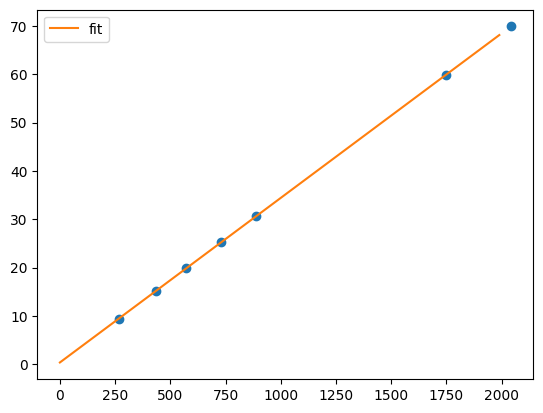

In [9]:
# verwerk hier jullie kalibratiemetingen
waarde_arduino = np.array([266,435,573,730,888,2042,1748])
afstand = np.array([10,15,20,25,30,70,60])

def model(waarde_arduino,a,b):
    return a*waarde_arduino+b

popt, pcov = curve_fit(model,waarde_arduino,afstand)
a = popt[0]
b = popt[1]

afstand = model(waarde_arduino,a,b)

plt.plot(waarde_arduino,afstand,'o')
print(a,b)

x = np.arange(0,2000,10)
y = a * x + b
plt.plot(x,y,label = 'fit')
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  40.50
1   0  30   0  20  40.36
2  40   0  30   0  41.70
3  30   0  20   0  41.50


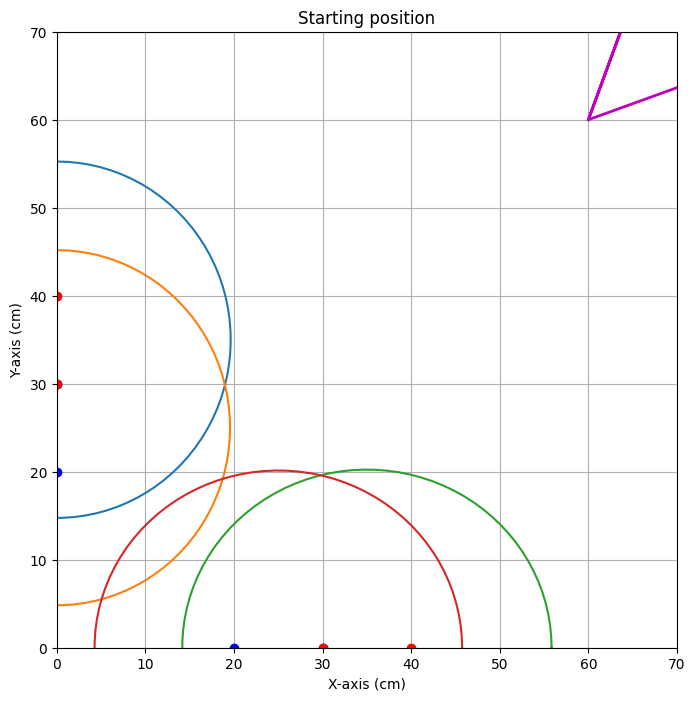


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.940
end iteration 2 with average mismatch=92.178


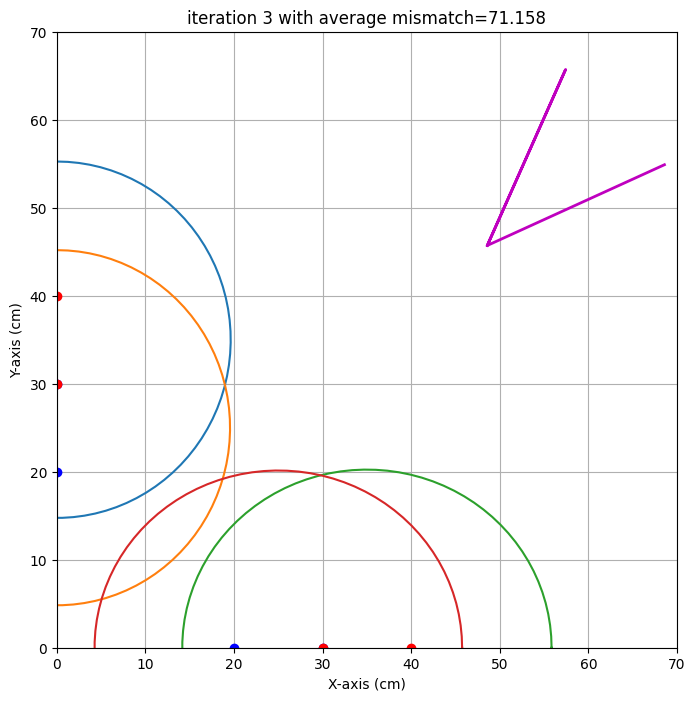

end iteration 3 with average mismatch=71.158


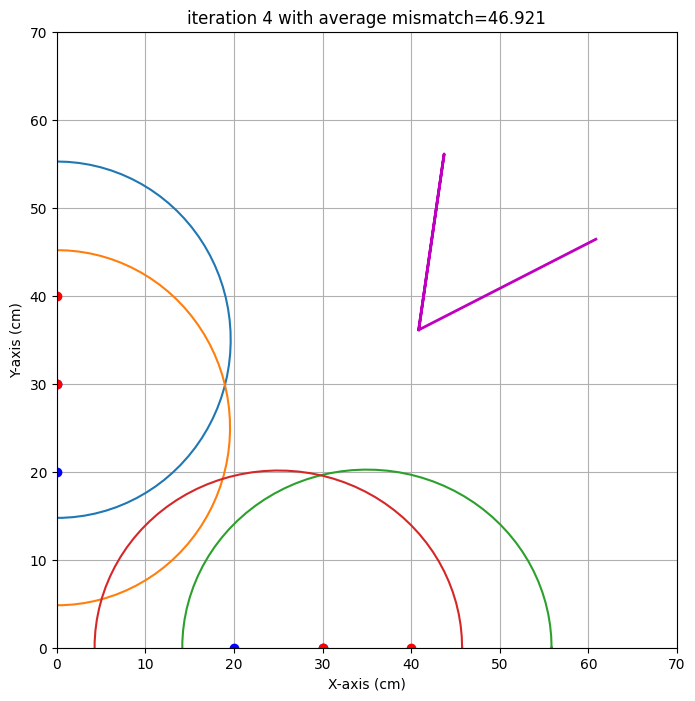

end iteration 4 with average mismatch=46.921


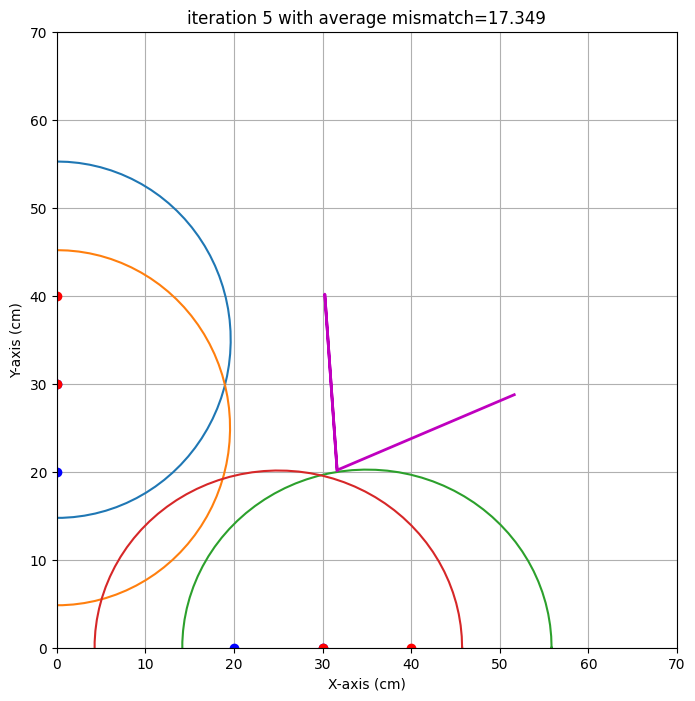

end iteration 5 with average mismatch=17.349


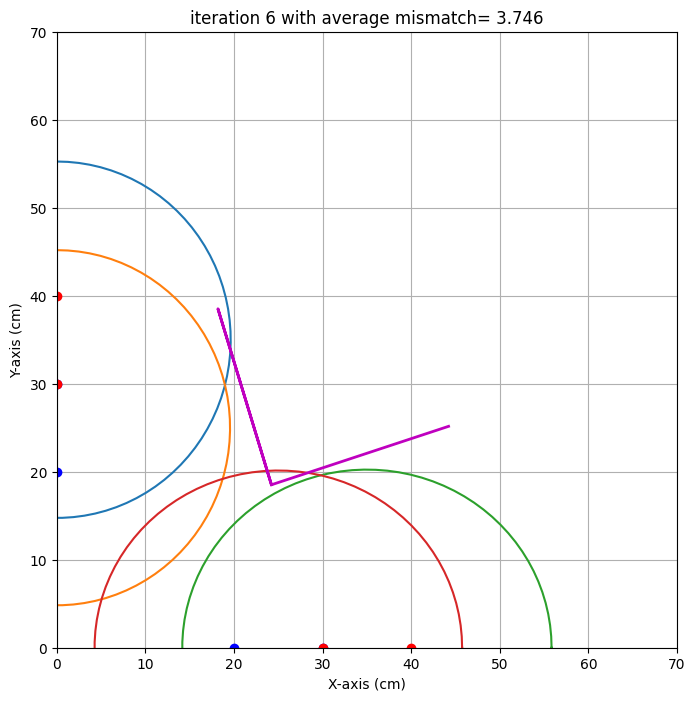

end iteration 6 with average mismatch= 3.746


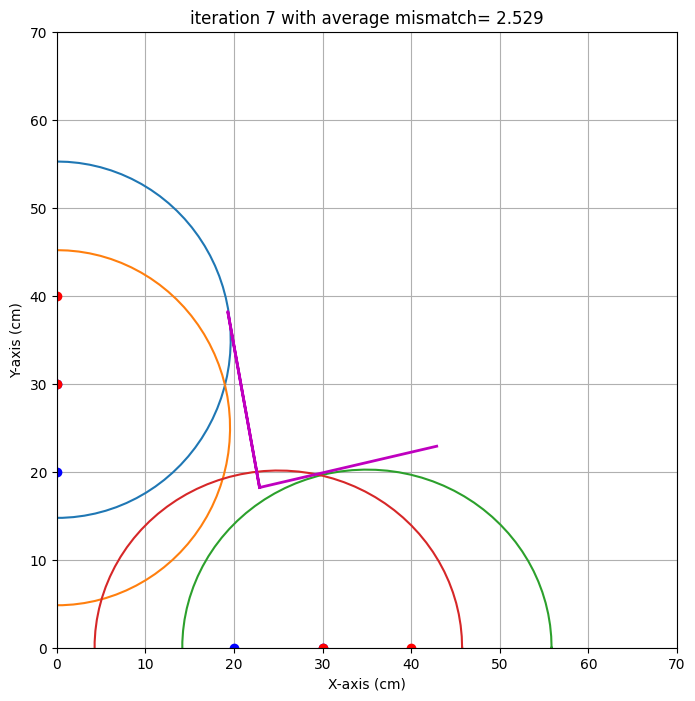

end iteration 7 with average mismatch= 2.529


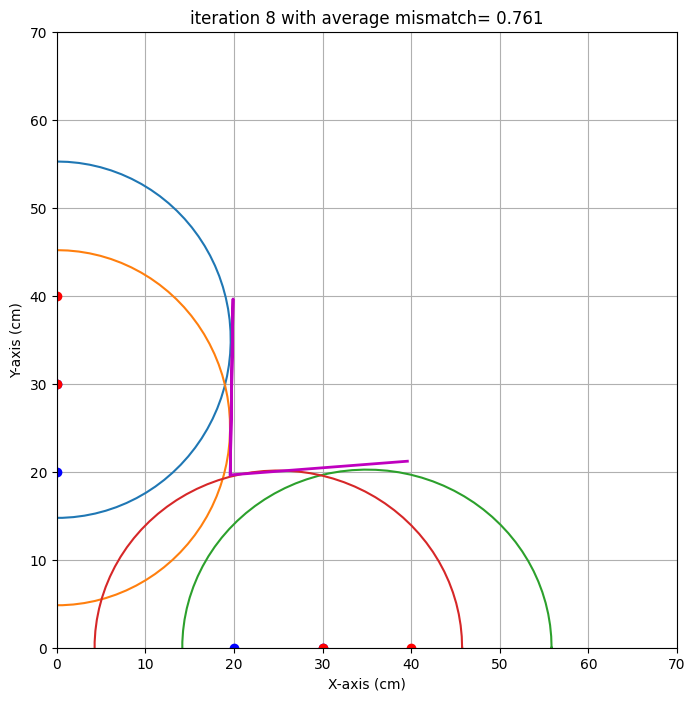

end iteration 8 with average mismatch= 0.761


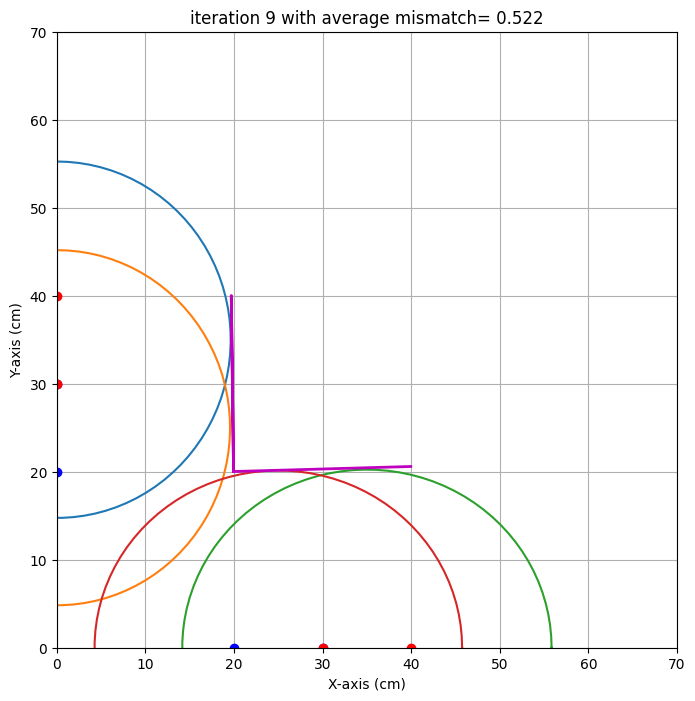

end iteration 9 with average mismatch= 0.522
end iteration 10 with average mismatch= 0.484
end iteration 11 with average mismatch= 0.477
end iteration 12 with average mismatch= 0.474


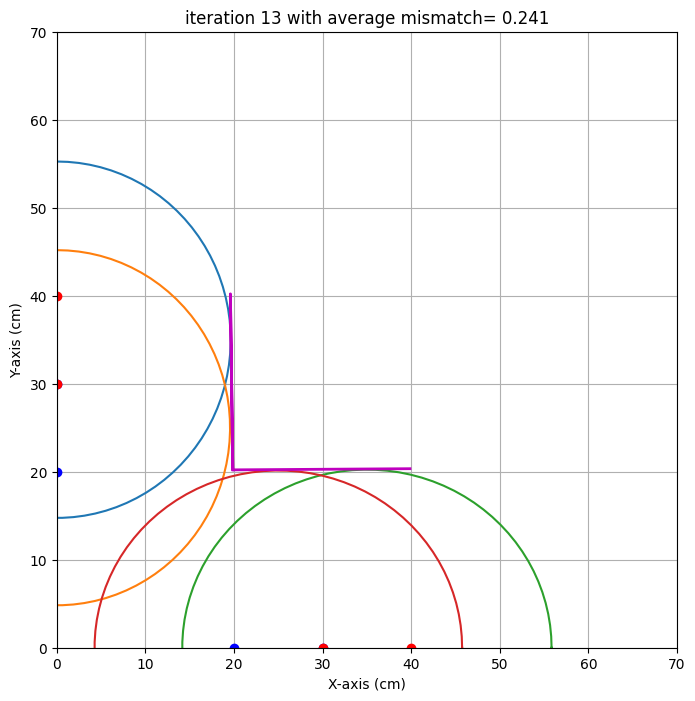

end iteration 13 with average mismatch= 0.241


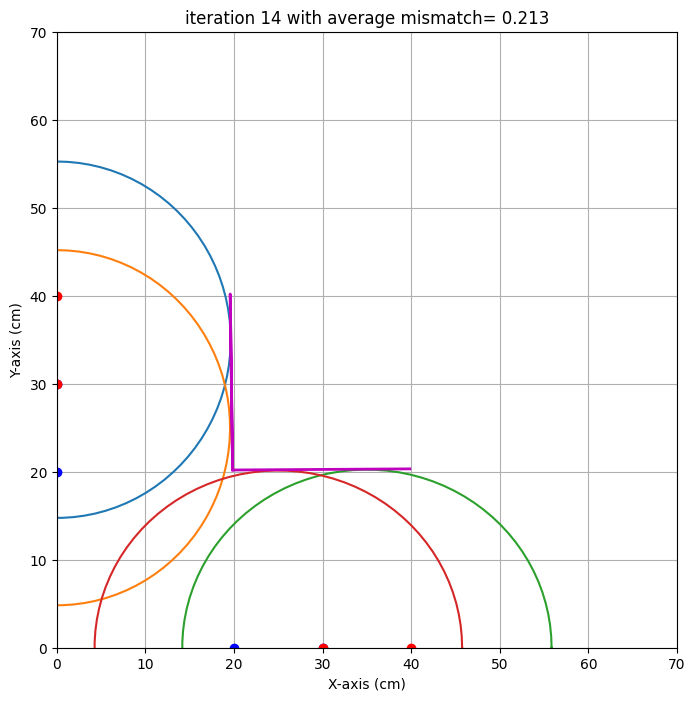

end iteration 14 with average mismatch= 0.213
end iteration 15 with average mismatch= 0.200
end iteration 16 with average mismatch= 0.199
end iteration 17 with average mismatch= 0.198
end iteration 18 with average mismatch= 0.198
end iteration 19 with average mismatch= 0.198
end iteration 20 with average mismatch= 0.198
end iteration 21 with average mismatch= 0.198
end iteration 22 with average mismatch= 0.198
end iteration 23 with average mismatch= 0.198
end iteration 24 with average mismatch= 0.198
end iteration 25 with average mismatch= 0.198
end iteration 26 with average mismatch= 0.198
end iteration 27 with average mismatch= 0.194
end iteration 28 with average mismatch= 0.181
end iteration 29 with average mismatch= 0.178
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.177
###########################################################

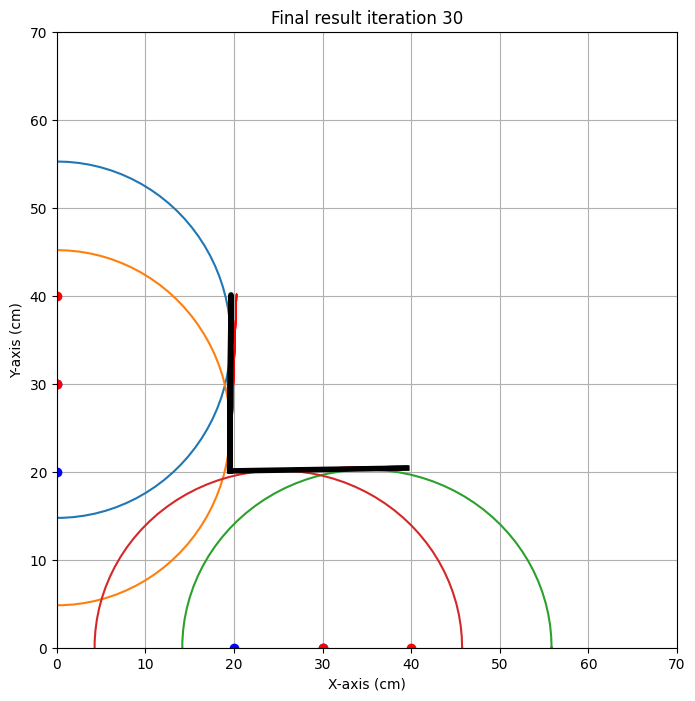

In [22]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.36],
    #[0,10,0,20,192.60],
    [40,0,30,0,41.70],
    [30,0,20,0,41.50],
    #[10,0,20,0,],
    #[10,0,0,10,22.87]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [23]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.5 cm met een standaardafwijking van 0.1 cm 
y0: 20.1 cm met een standaardafwijking van 0.1 cm 
alpha: 0.9 graden met een standaardafwijking van 0.3 graad 
beta: 0.4 graden met een standaardafwijking van 1.6 graad 



## Opdracht 5: Iteratie 0

Tussen 40 en 110 telt als logische meting

#### algoritme [Teun]
<img src="schets1.jpeg" width="350">

#### algoritme [Hugo]
<img src="schets2.jpeg" width="350">

#### algoritme [Nina]
<img src="schets3.jpeg" width="350">

## Opdracht 6: Test iteratie 0.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': 38,
           'alpha': 1,
           'beta' : 1
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Teun' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,79.05],
    [50,0,60,0,83.60],
    [0,40,0,50,61.10],
    [0,50,0,60,59.60]
    ]),
       'Hugo' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   [40,0,30,0,82.80],
   [30,0,20,0,98.50],
   #Niet logisch[0,40,0,30,],
   [0,50,0,40,59.35],
   [0,60,0,50,55.0]
    ])
      }

## Opdracht 7: Evaluatie.

Teun
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  50   0  79.05
1  50   0  60   0  83.60
2   0  40   0  50  61.10
3   0  50   0  60  59.60


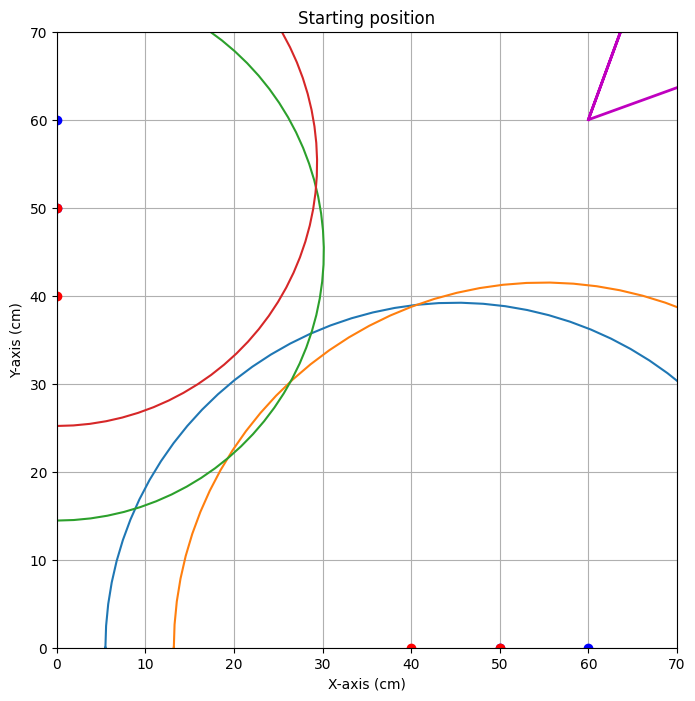


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.735


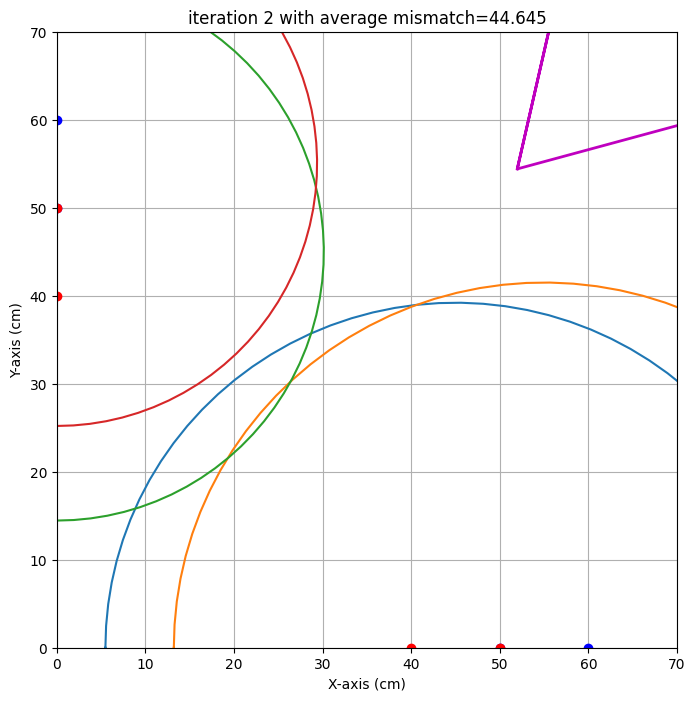

end iteration 2 with average mismatch=44.645


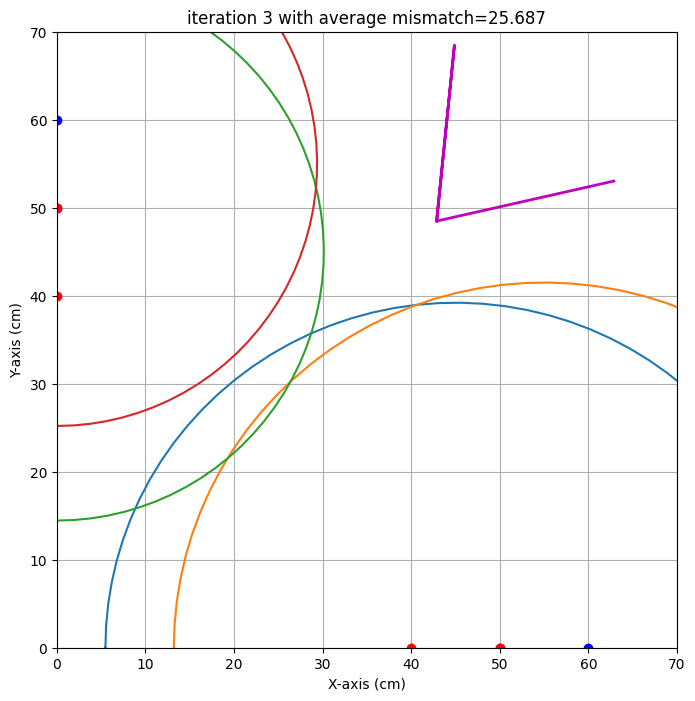

end iteration 3 with average mismatch=25.687


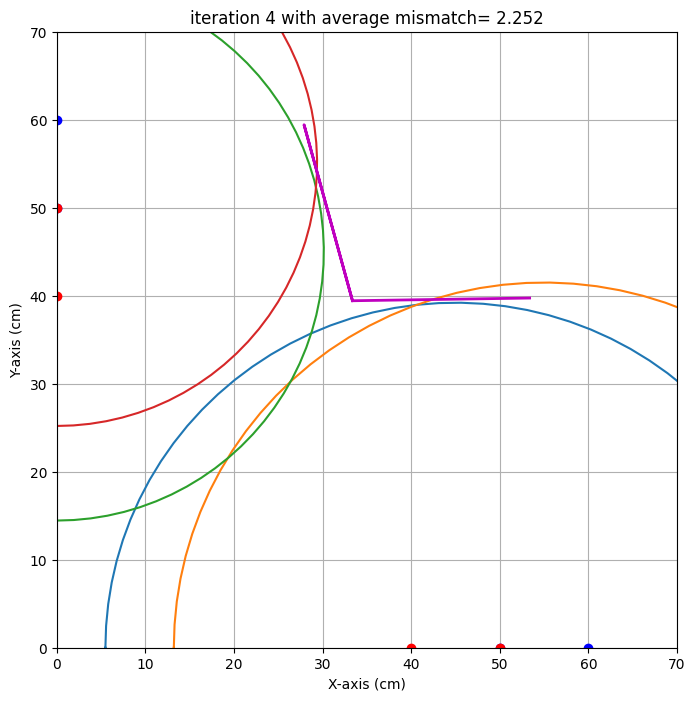

end iteration 4 with average mismatch= 2.252


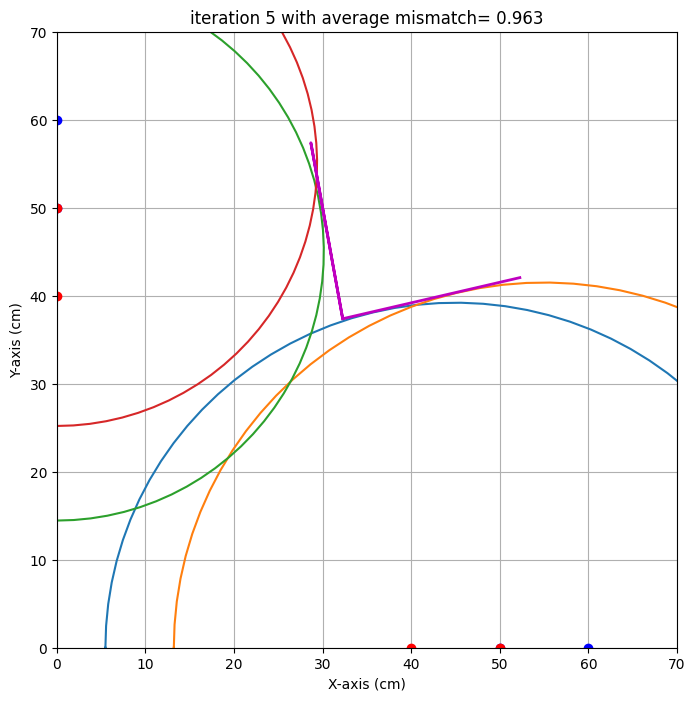

end iteration 5 with average mismatch= 0.963
end iteration 6 with average mismatch= 0.958


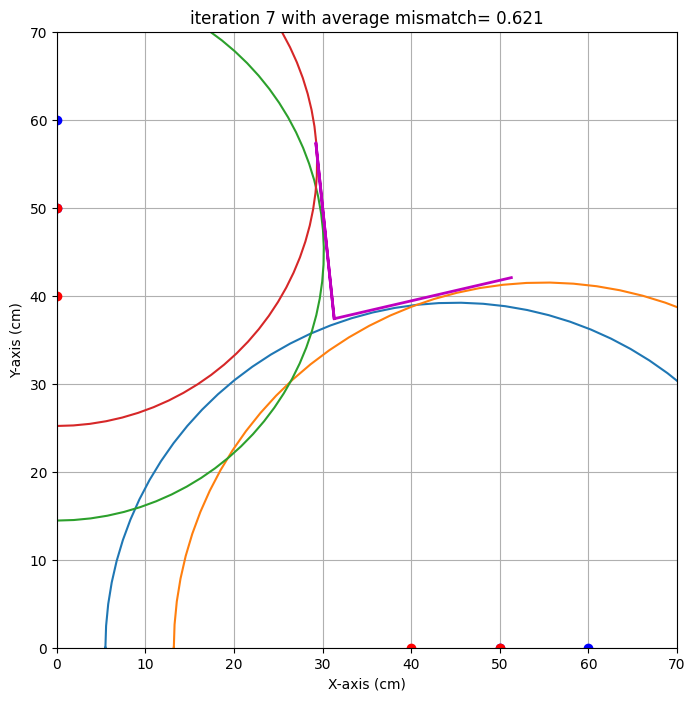

end iteration 7 with average mismatch= 0.621
end iteration 8 with average mismatch= 0.586


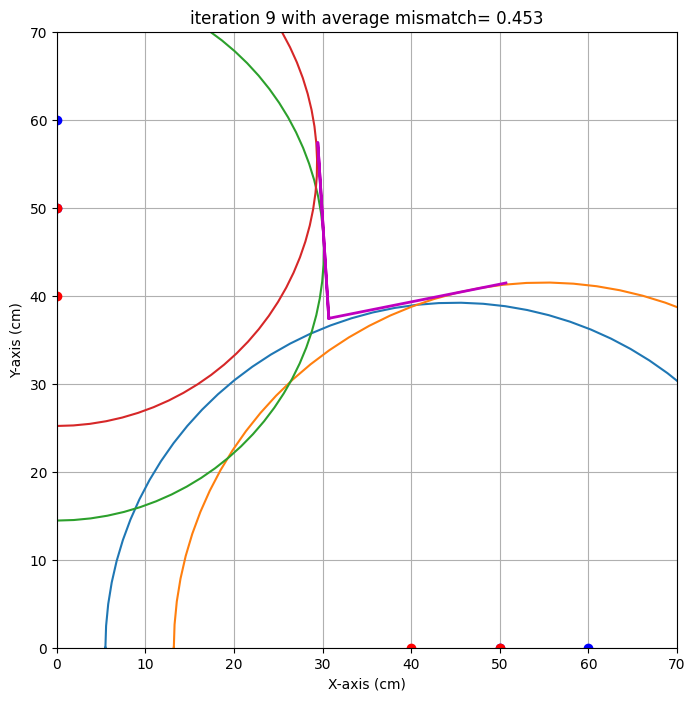

end iteration 9 with average mismatch= 0.453
end iteration 10 with average mismatch= 0.428
end iteration 11 with average mismatch= 0.425
end iteration 12 with average mismatch= 0.425
end iteration 13 with average mismatch= 0.425
end iteration 14 with average mismatch= 0.425


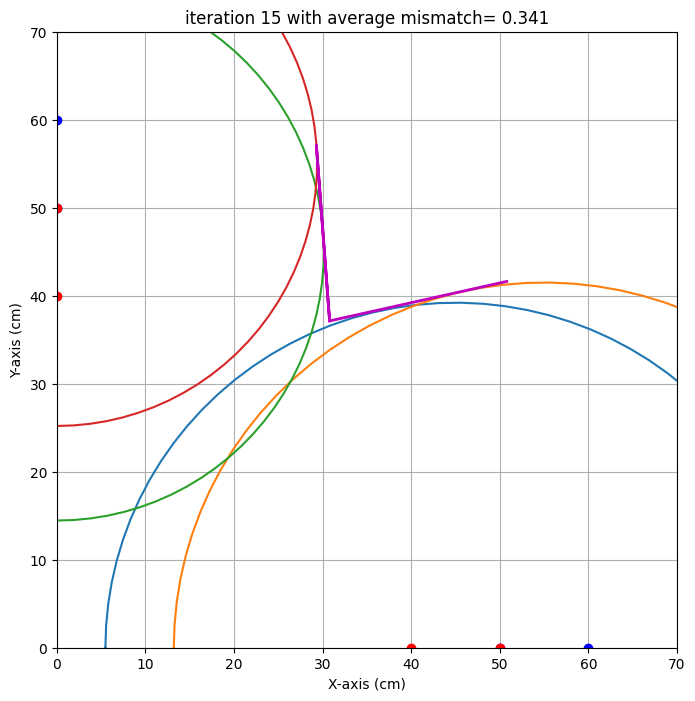

end iteration 15 with average mismatch= 0.341
end iteration 16 with average mismatch= 0.337
end iteration 17 with average mismatch= 0.337
end iteration 18 with average mismatch= 0.337
end iteration 19 with average mismatch= 0.337
end iteration 20 with average mismatch= 0.337
end iteration 21 with average mismatch= 0.337
end iteration 22 with average mismatch= 0.337
end iteration 23 with average mismatch= 0.337
end iteration 24 with average mismatch= 0.337
end iteration 25 with average mismatch= 0.337
end iteration 26 with average mismatch= 0.337
end iteration 27 with average mismatch= 0.337
end iteration 28 with average mismatch= 0.337
end iteration 29 with average mismatch= 0.337
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.337
###############################################################################
end of iteration  30
Best alpha=  12.65 with uncertainty=   2.36
Best beta 

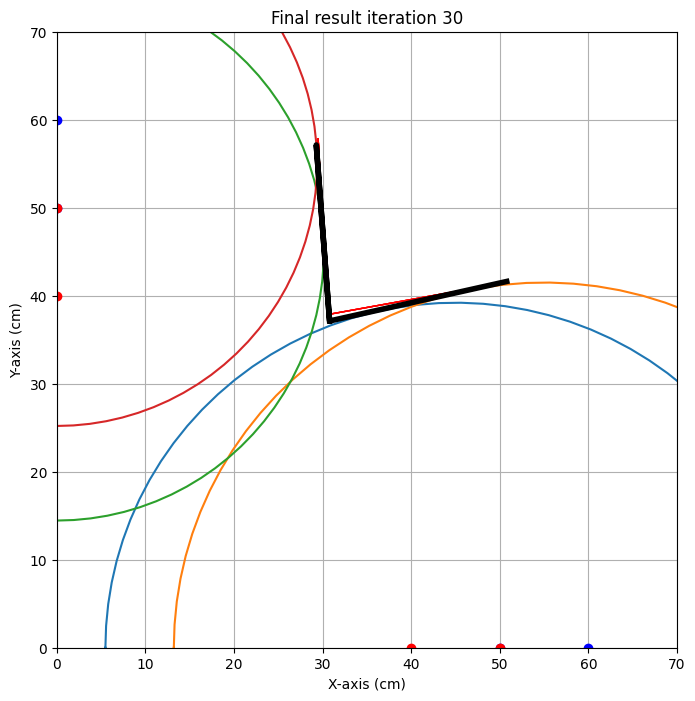

{'alpha': np.float64(12.650328105642402), 'alpha_eps': np.float64(2.362175426905921), 'beta': np.float64(-4.298753183738042), 'beta_eps': np.float64(1.3063477643162535), 'x0': np.float64(30.785263287211773), 'x0_eps': np.float64(0.24625044362483806), 'y0': np.float64(37.13118016858395), 'y0_eps': np.float64(0.7218885276046336)}
Hugo
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  30   0  82.80
1  30   0  20   0  98.50
2   0  50   0  40  59.35
3   0  60   0  50  55.00


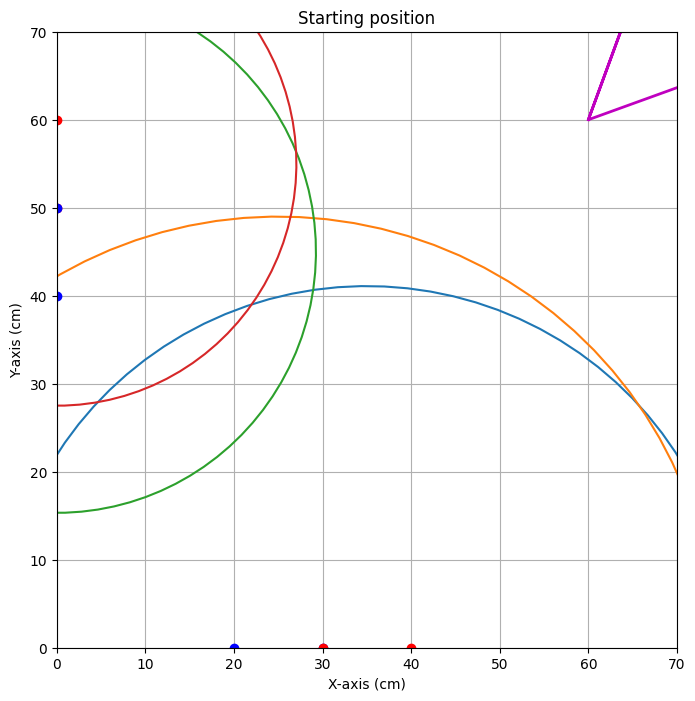


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.642


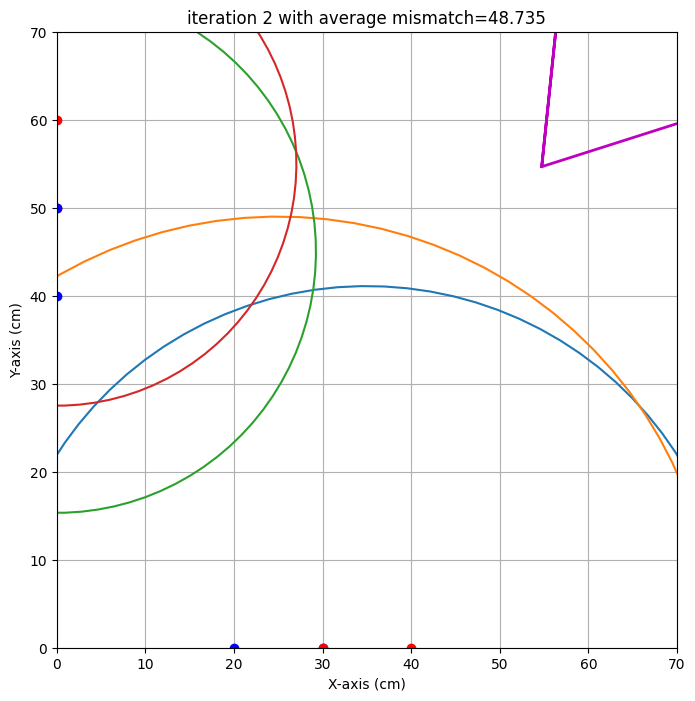

end iteration 2 with average mismatch=48.735


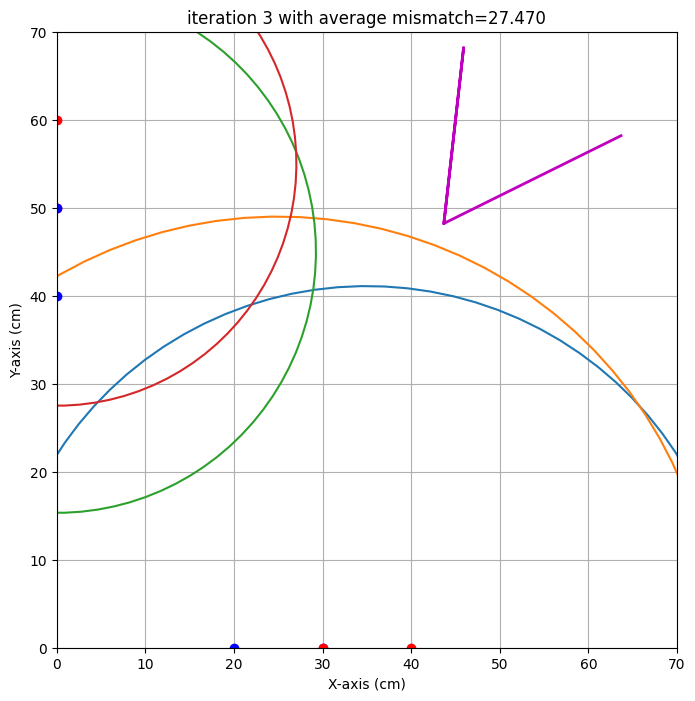

end iteration 3 with average mismatch=27.470


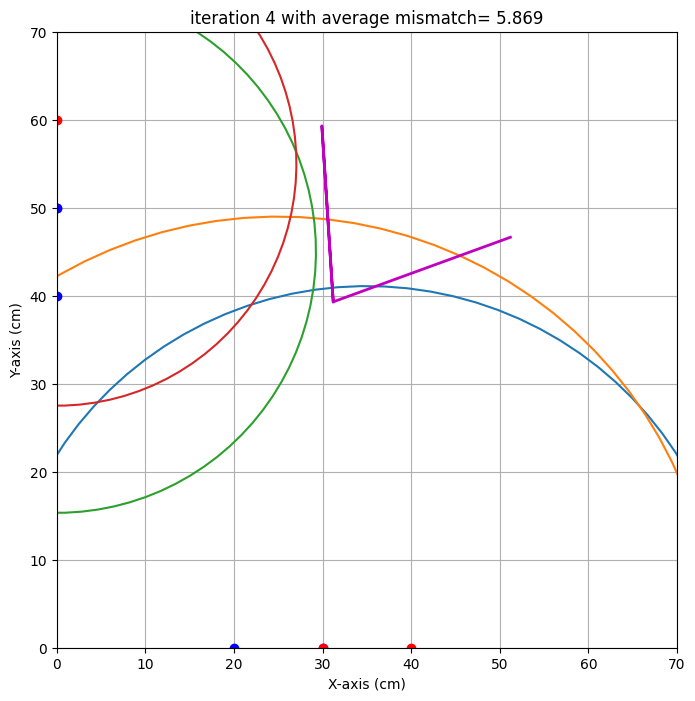

end iteration 4 with average mismatch= 5.869


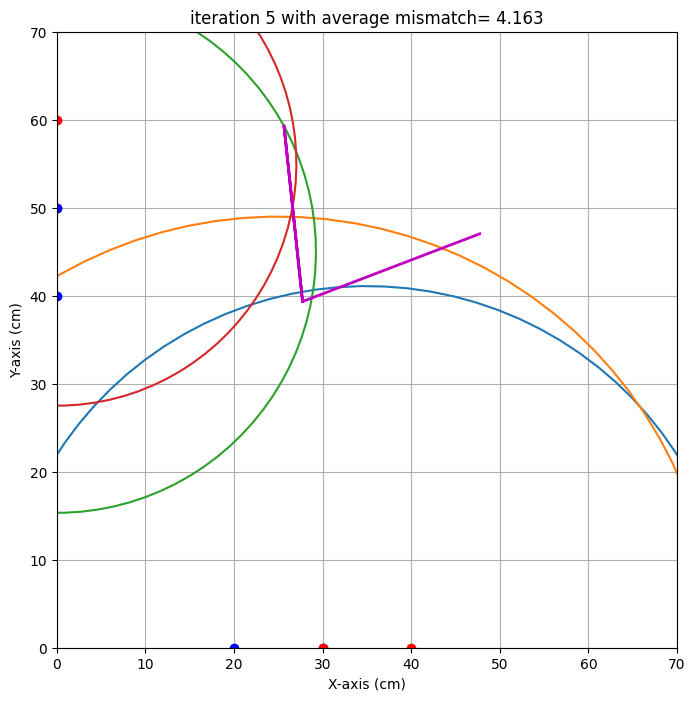

end iteration 5 with average mismatch= 4.163


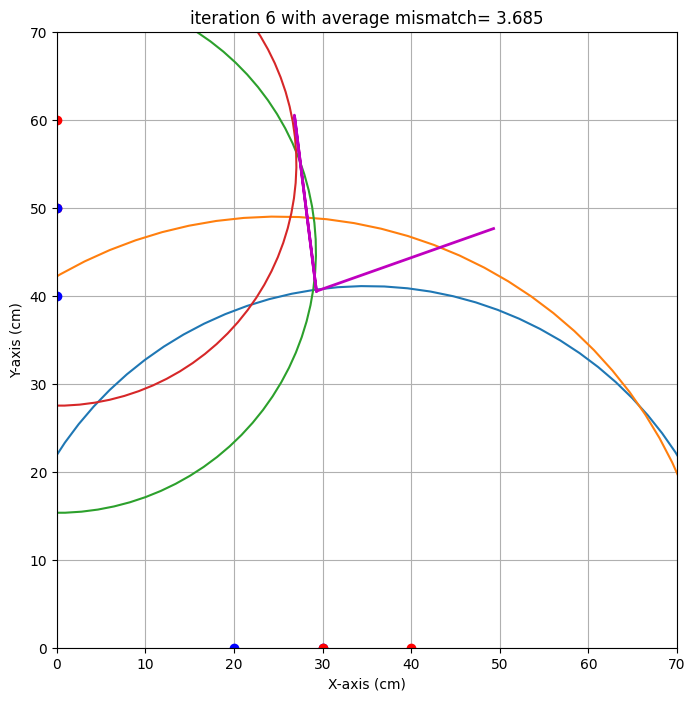

end iteration 6 with average mismatch= 3.685


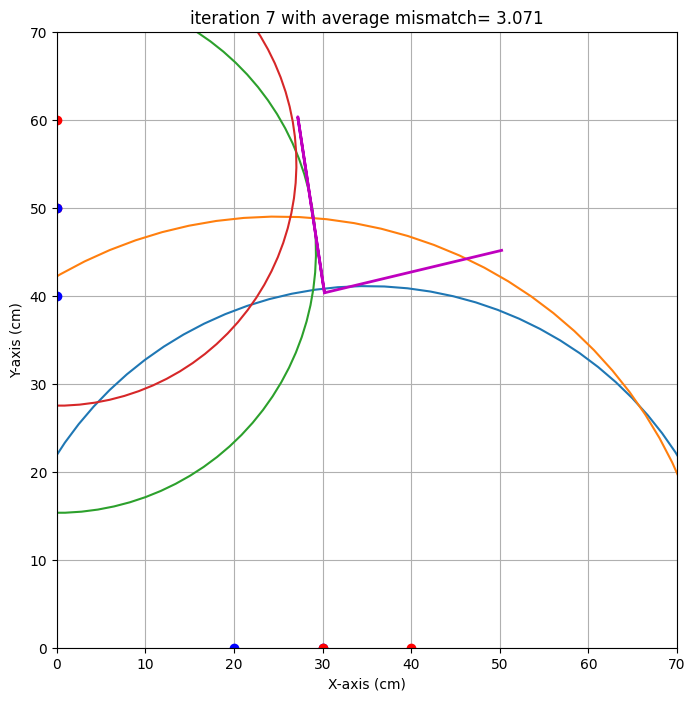

end iteration 7 with average mismatch= 3.071
end iteration 8 with average mismatch= 2.887


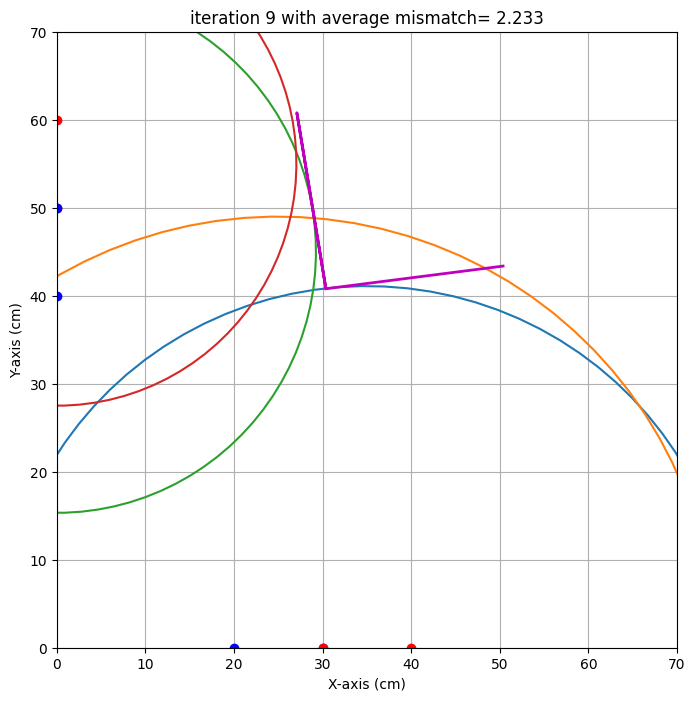

end iteration 9 with average mismatch= 2.233
end iteration 10 with average mismatch= 2.233
end iteration 11 with average mismatch= 2.233
end iteration 12 with average mismatch= 2.233
end iteration 13 with average mismatch= 2.177
end iteration 14 with average mismatch= 2.034
end iteration 15 with average mismatch= 2.021
end iteration 16 with average mismatch= 2.010
end iteration 17 with average mismatch= 2.010
end iteration 18 with average mismatch= 1.967
end iteration 19 with average mismatch= 1.963
end iteration 20 with average mismatch= 1.963
end iteration 21 with average mismatch= 1.963
end iteration 22 with average mismatch= 1.963
end iteration 23 with average mismatch= 1.963
end iteration 24 with average mismatch= 1.963
end iteration 25 with average mismatch= 1.963
end iteration 26 with average mismatch= 1.963
end iteration 27 with average mismatch= 1.963
end iteration 28 with average mismatch= 1.963
end iteration 29 with average mismatch= 1.963
Last iteration, also determine unce

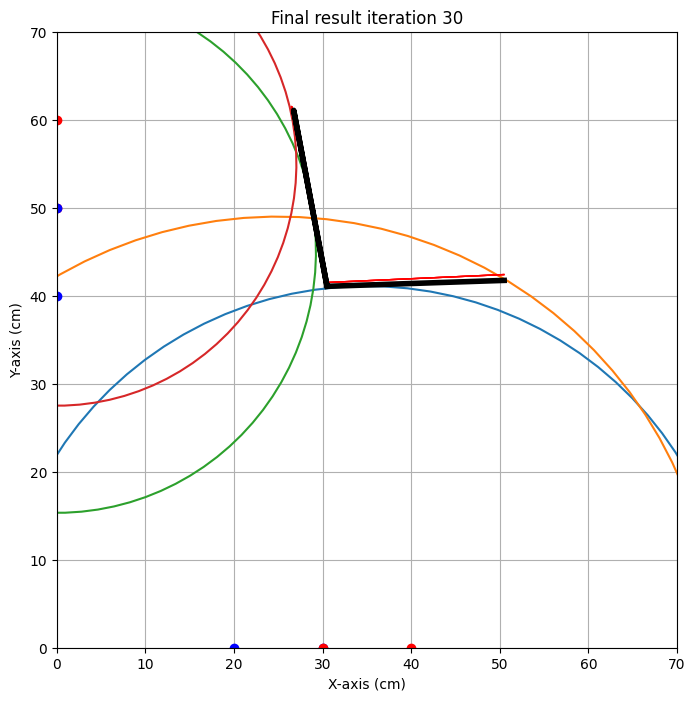

{'alpha': np.float64(1.9286308876374747), 'alpha_eps': np.float64(0.6532717404820554), 'beta': np.float64(-10.65923820760734), 'beta_eps': np.float64(0.5435440668357767), 'x0': np.float64(30.499020607508033), 'x0_eps': np.float64(0.04705436083941095), 'y0': np.float64(41.06769750102373), 'y0_eps': np.float64(0.4342448816988096)}


In [40]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [38]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Teun 
x0 target is : 33.0. Gevonden waarde: 30.7 cm met een standaardafwijking van 0.4 cm 
y0 target is : 38.0. Gevonden waarde: 37.4 cm met een standaardafwijking van 0.3 cm 
alpha target is : 1.0. Gevonden waarde: 11.4 graden met een standaardafwijking van 1.2 graad 
beta target is : 1.0. Gevonden waarde: -3.7 graden met een standaardafwijking van 2.0 graad 

Hugo 
x0 target is : 33.0. Gevonden waarde: 31.2 cm met een standaardafwijking van 0.3 cm 
y0 target is : 38.0. Gevonden waarde: 41.1 cm met een standaardafwijking van 0.7 cm 
alpha target is : 1.0. Gevonden waarde: 0.3 graden met een standaardafwijking van 0.8 graad 
beta target is : 1.0. Gevonden waarde: -13.6 graden met een standaardafwijking van 1.8 graad 



## Opdracht 8: Iteratie1+ 15:00
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt]()


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [ ]:
data11 ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [40,0,40,0,69.9],
    [45,0,60,0,72.35],
    [0,40,0,50,61.15],
    [0,45,0,60,62.27]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [40,0,50,0,91.2],
    [45,0,60,0,92.6],
    [0,40,0,50,61.10],
    [0,45,0,60,58.70]
    ])
      }

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  40   0  69.90
1  45   0  60   0  72.35
2   0  40   0  50  61.15
3   0  45   0  60  62.27


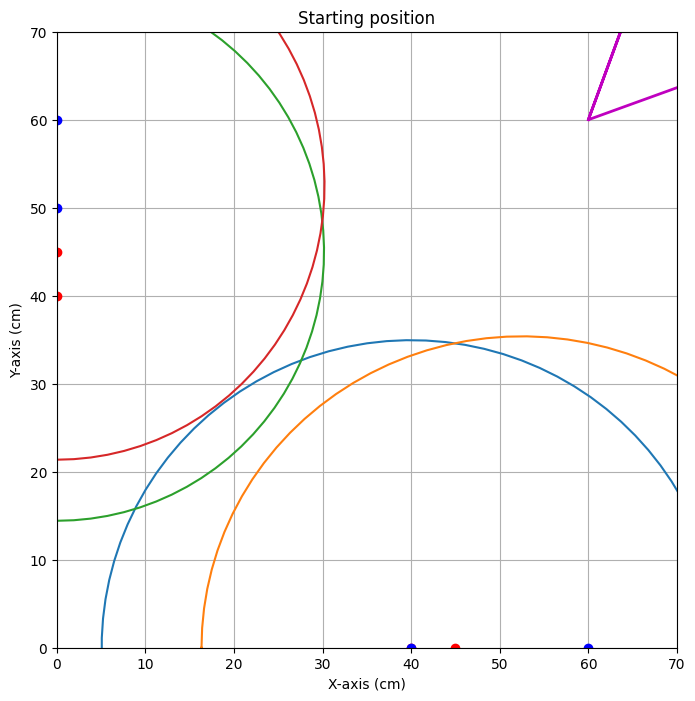


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.348


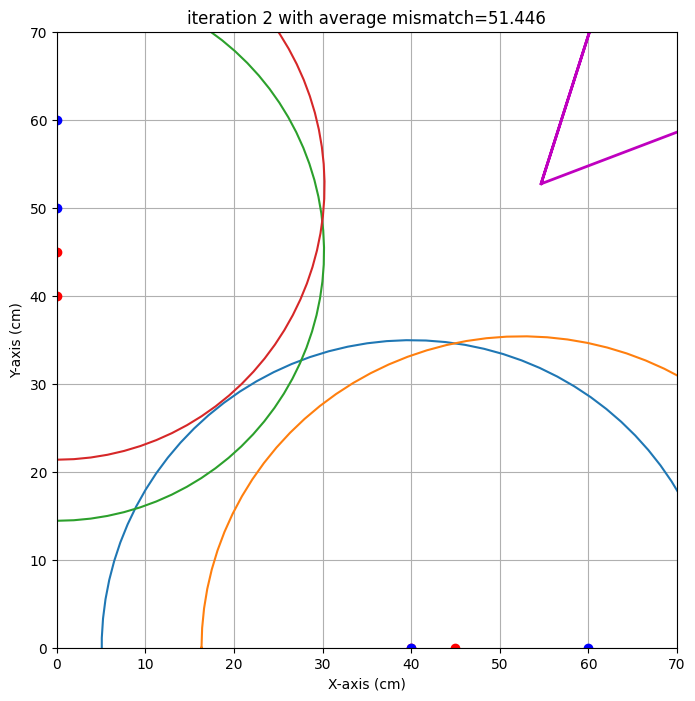

end iteration 2 with average mismatch=51.446


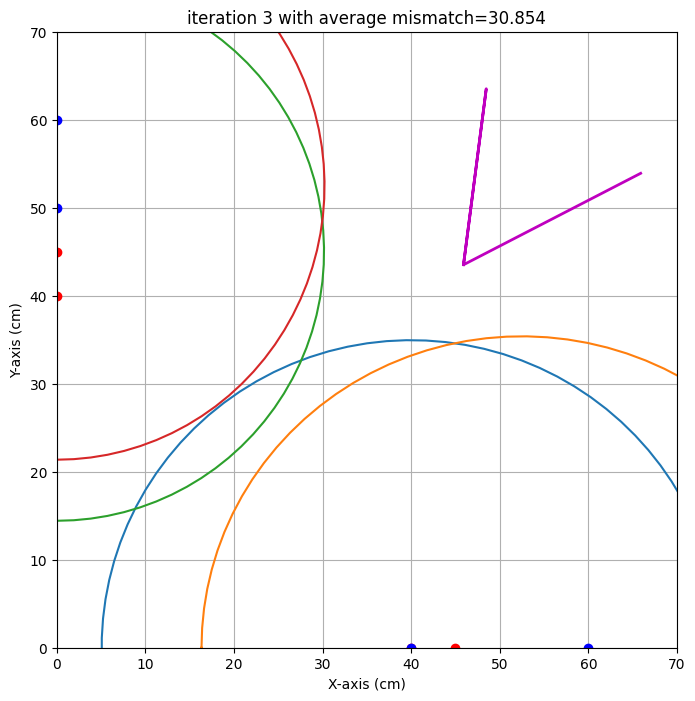

end iteration 3 with average mismatch=30.854


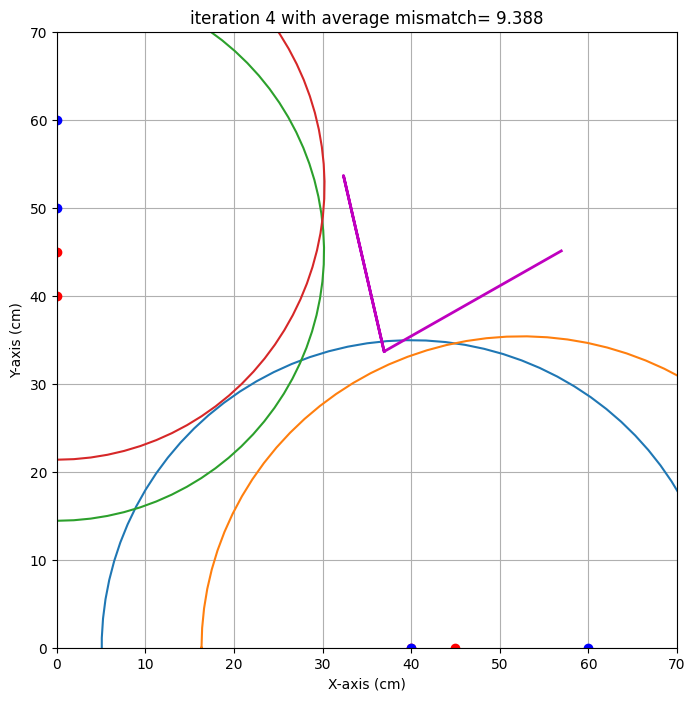

end iteration 4 with average mismatch= 9.388


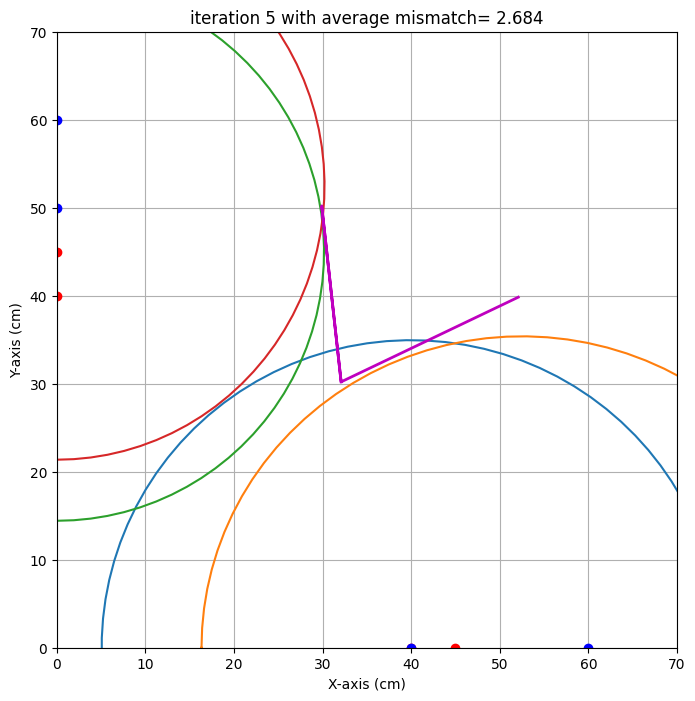

end iteration 5 with average mismatch= 2.684
end iteration 6 with average mismatch= 2.526


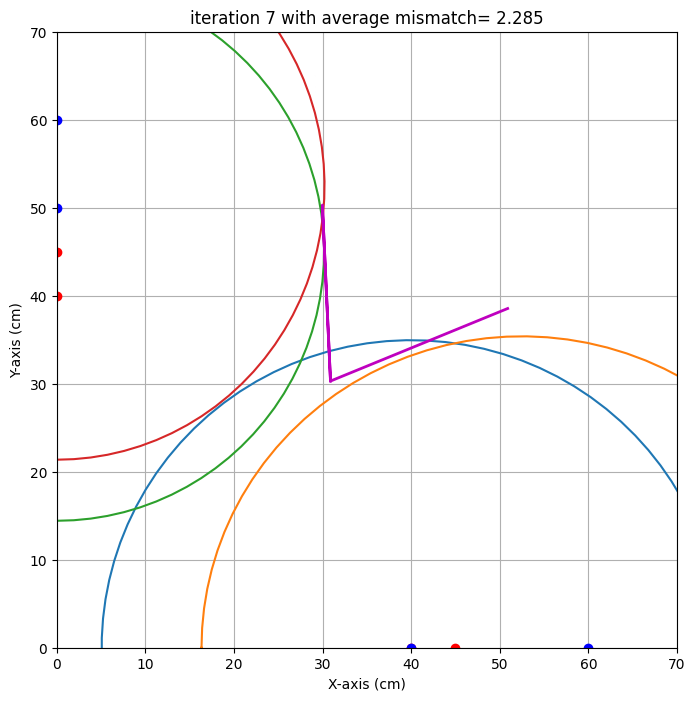

end iteration 7 with average mismatch= 2.285
end iteration 8 with average mismatch= 2.285


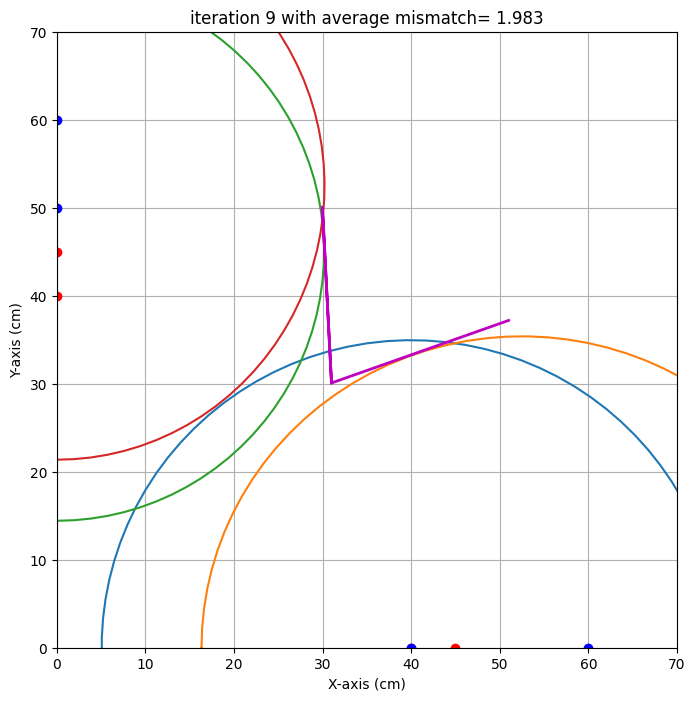

end iteration 9 with average mismatch= 1.983
end iteration 10 with average mismatch= 1.983
end iteration 11 with average mismatch= 1.983
end iteration 12 with average mismatch= 1.983
end iteration 13 with average mismatch= 1.967
end iteration 14 with average mismatch= 1.947


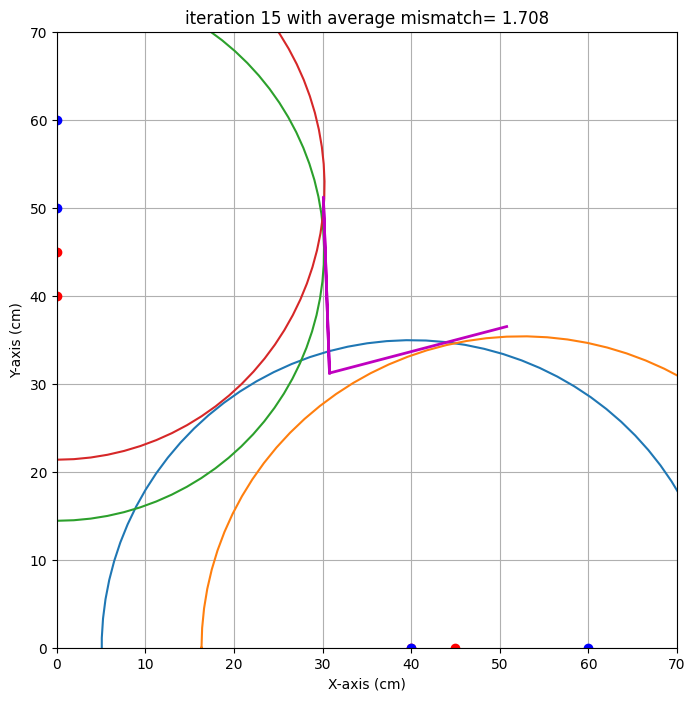

end iteration 15 with average mismatch= 1.708
end iteration 16 with average mismatch= 1.708
end iteration 17 with average mismatch= 1.708


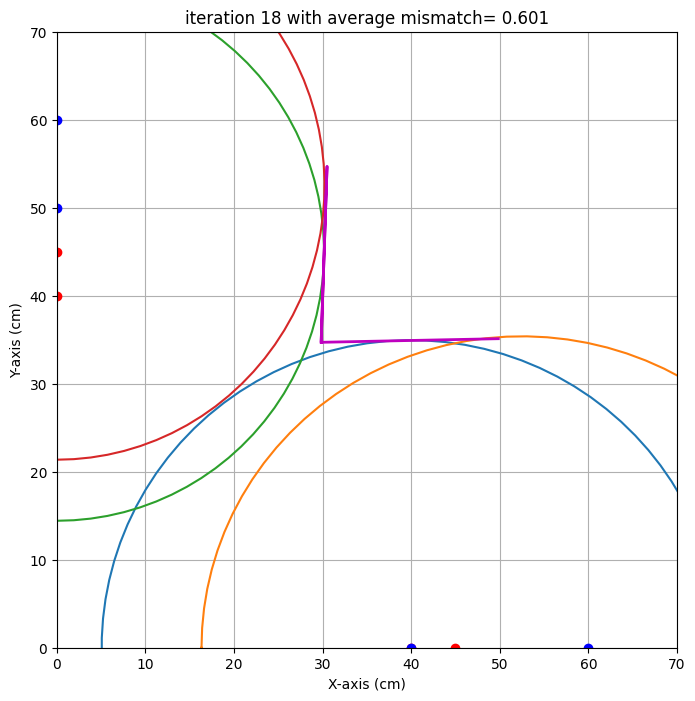

end iteration 18 with average mismatch= 0.601


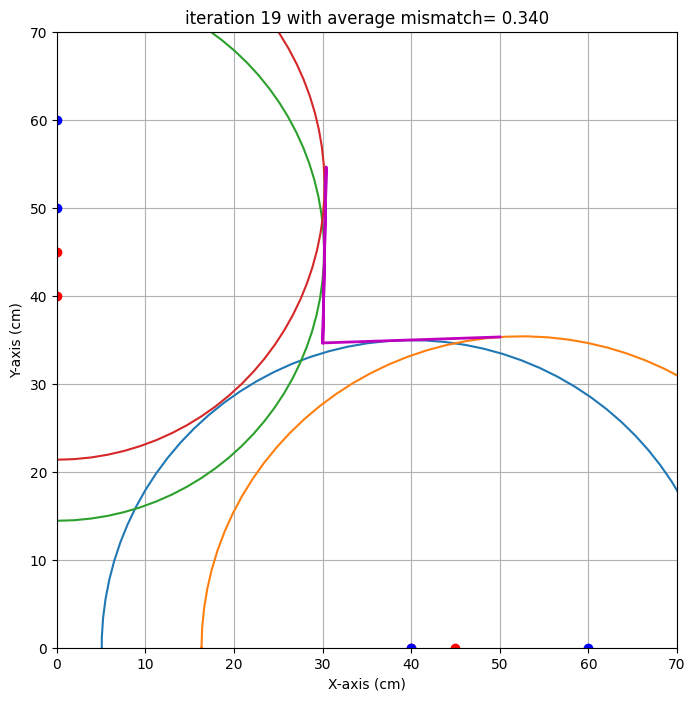

end iteration 19 with average mismatch= 0.340
end iteration 20 with average mismatch= 0.329
end iteration 21 with average mismatch= 0.326
end iteration 22 with average mismatch= 0.326
end iteration 23 with average mismatch= 0.326
end iteration 24 with average mismatch= 0.319
end iteration 25 with average mismatch= 0.294
end iteration 26 with average mismatch= 0.294
end iteration 27 with average mismatch= 0.294
end iteration 28 with average mismatch= 0.294
end iteration 29 with average mismatch= 0.294
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.294
###############################################################################
end of iteration  30
Best alpha=   3.26 with uncertainty=   2.82
Best beta =   0.51 with uncertainty=   1.87
Best x0   =  30.07 with uncertainty=   0.57
Best y0   =  34.44 with uncertainty=   0.55
############

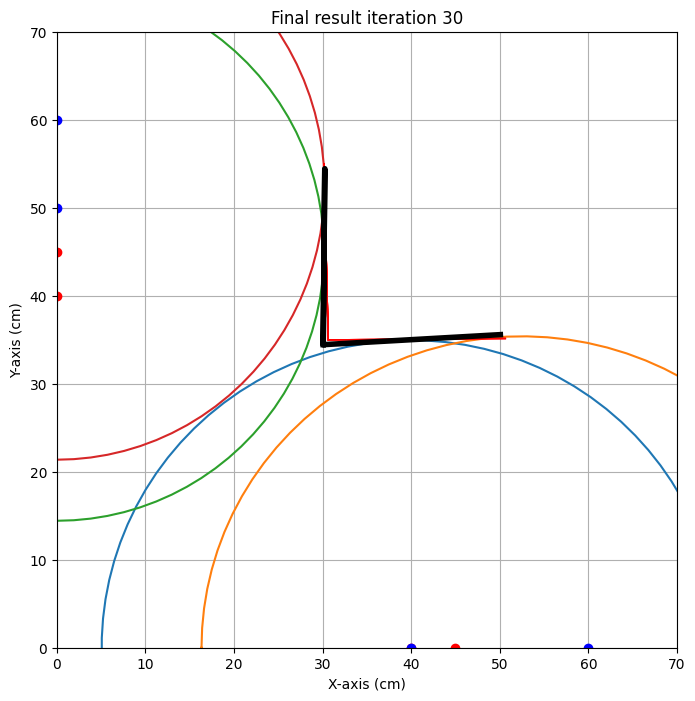

{'alpha': np.float64(3.2598205382513896), 'alpha_eps': np.float64(2.8228104069755253), 'beta': np.float64(0.5072865424087842), 'beta_eps': np.float64(1.8748494546328365), 'x0': np.float64(30.066335785624766), 'x0_eps': np.float64(0.5665182845021199), 'y0': np.float64(34.437862880362474), 'y0_eps': np.float64(0.5479156842884336)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  91.2
1  45   0  60   0  92.6
2   0  40   0  50  61.1
3   0  45   0  60  58.7


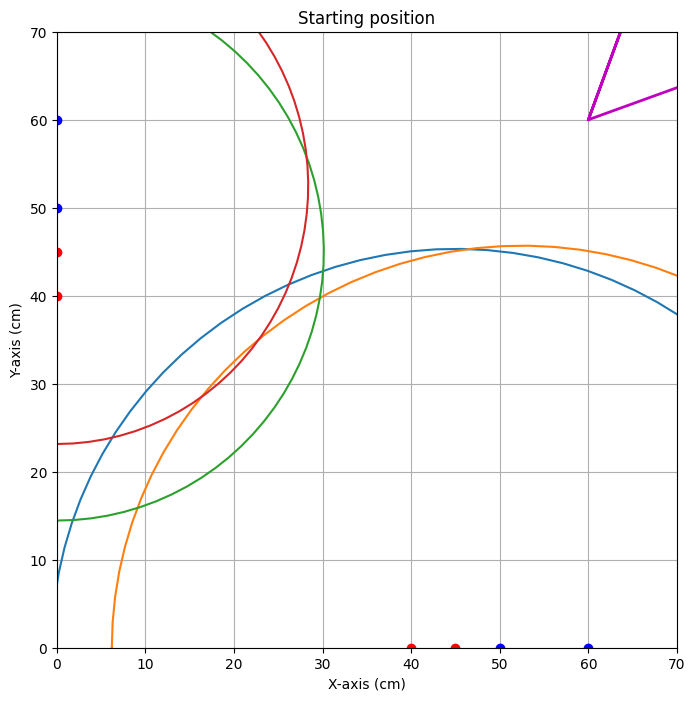


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.269


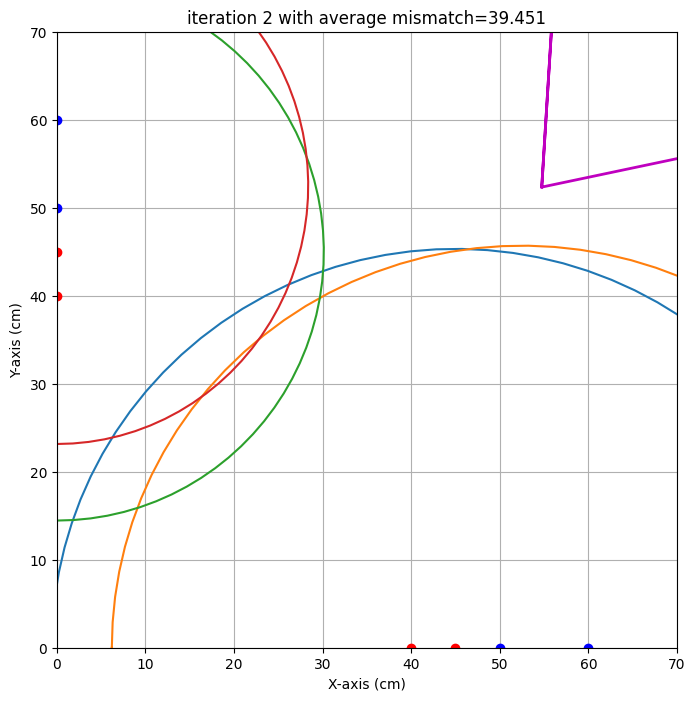

end iteration 2 with average mismatch=39.451


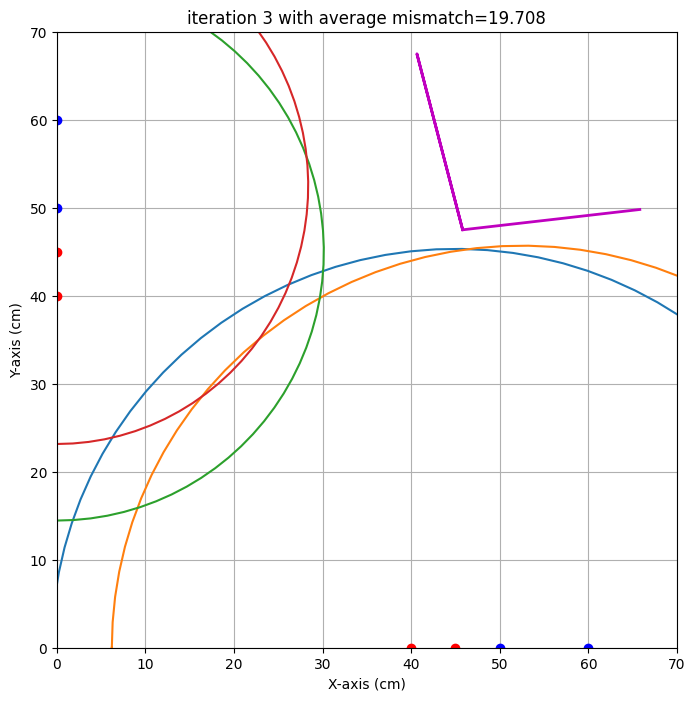

end iteration 3 with average mismatch=19.708


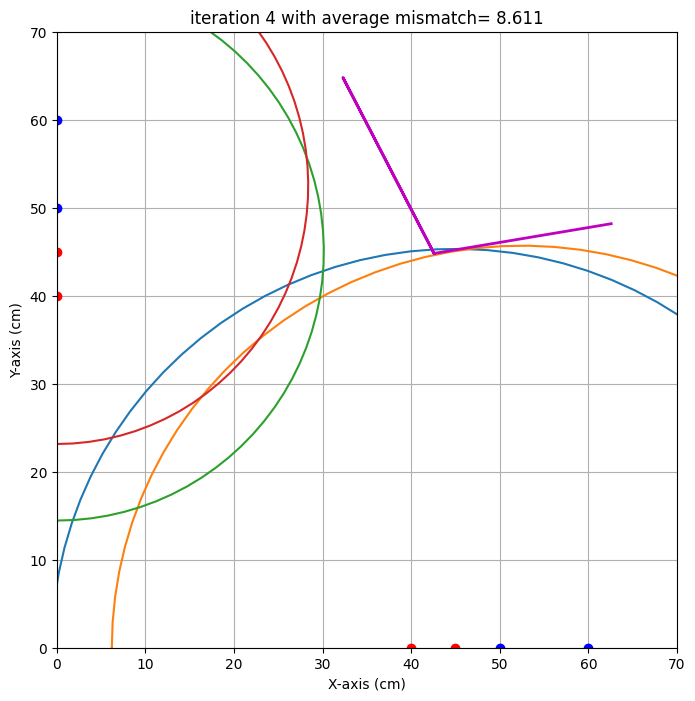

end iteration 4 with average mismatch= 8.611


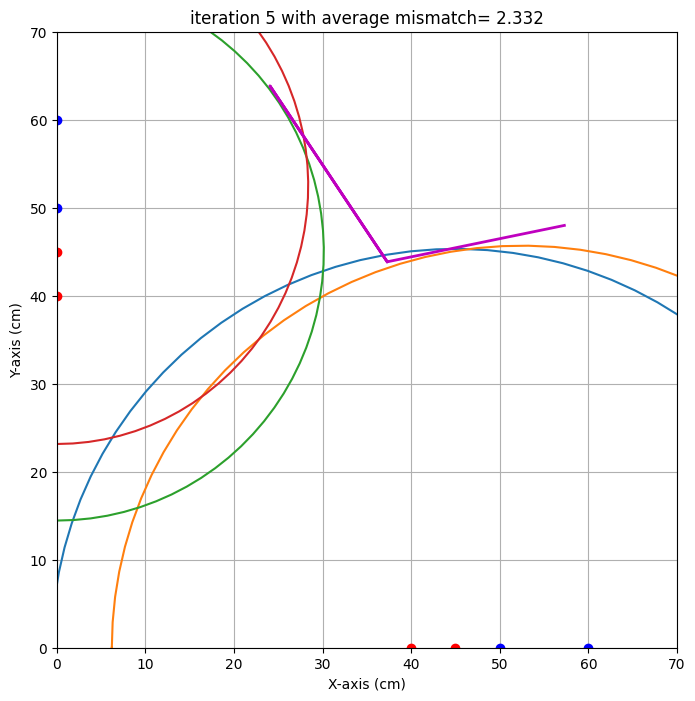

end iteration 5 with average mismatch= 2.332


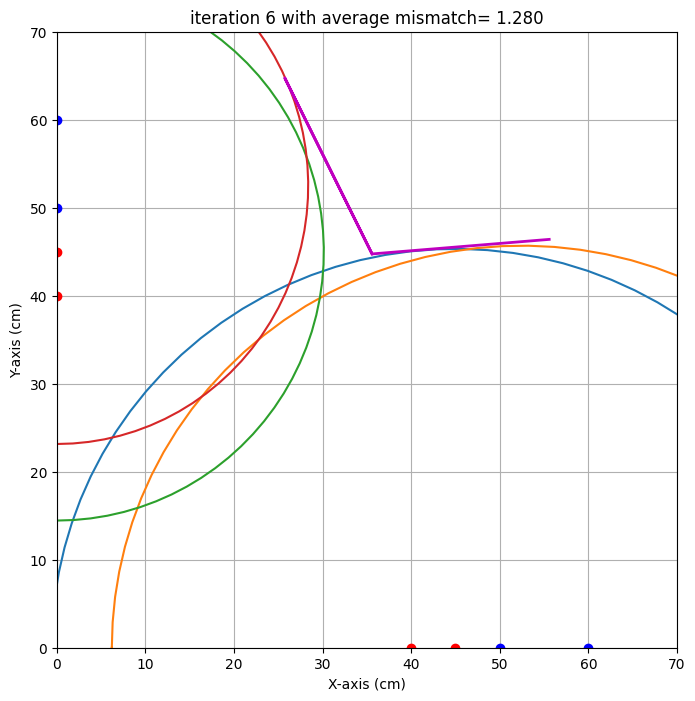

end iteration 6 with average mismatch= 1.280
end iteration 7 with average mismatch= 1.252
end iteration 8 with average mismatch= 1.252
end iteration 9 with average mismatch= 1.252
end iteration 10 with average mismatch= 1.219


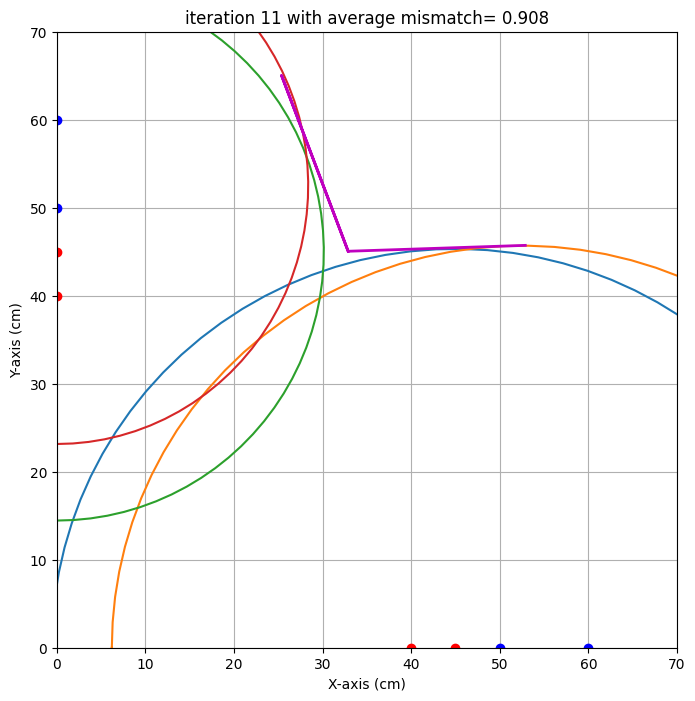

end iteration 11 with average mismatch= 0.908


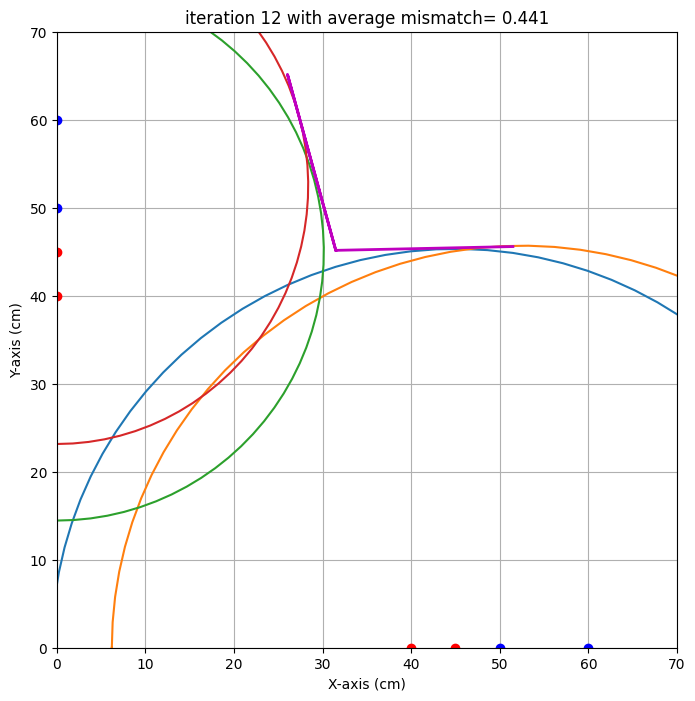

end iteration 12 with average mismatch= 0.441


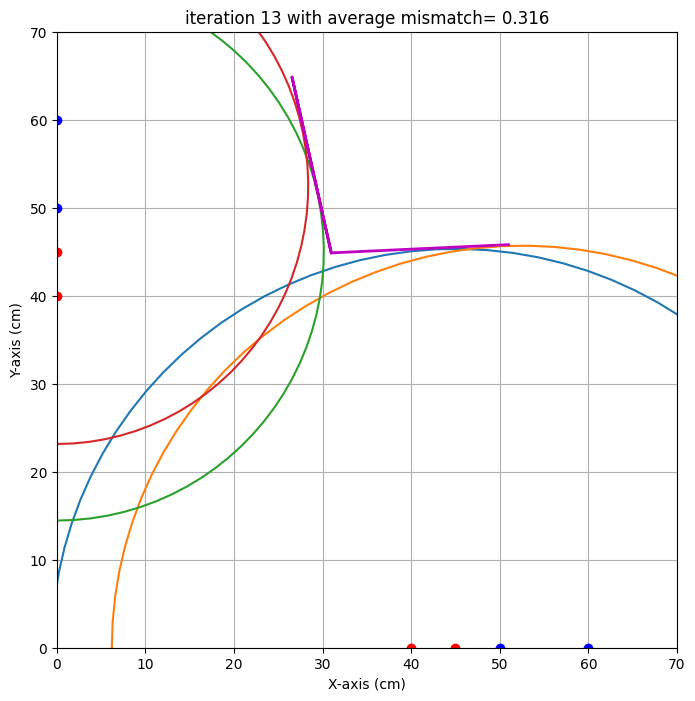

end iteration 13 with average mismatch= 0.316


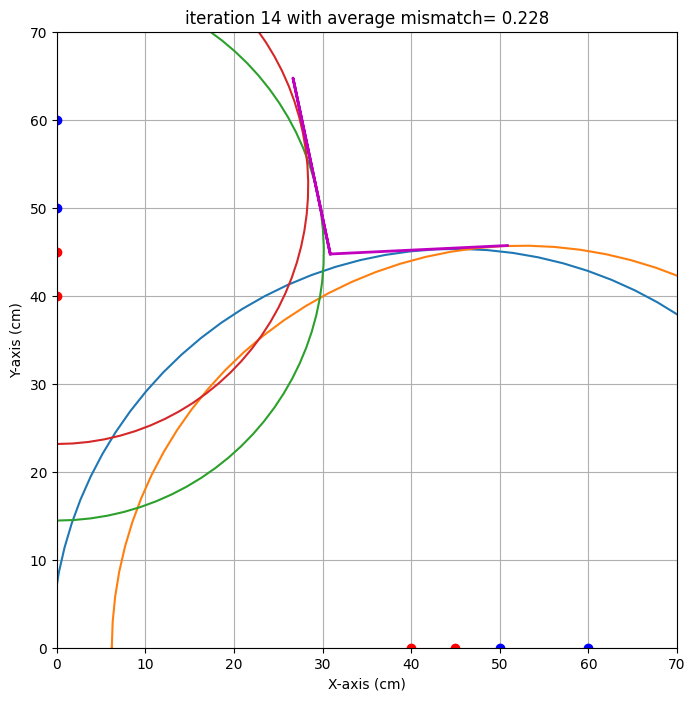

end iteration 14 with average mismatch= 0.228
end iteration 15 with average mismatch= 0.218
end iteration 16 with average mismatch= 0.216
end iteration 17 with average mismatch= 0.215


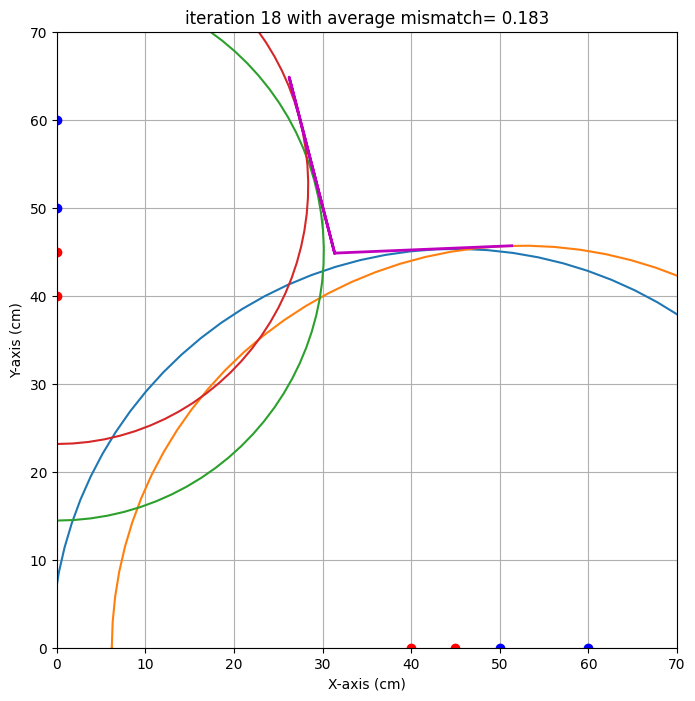

end iteration 18 with average mismatch= 0.183
end iteration 19 with average mismatch= 0.176
end iteration 20 with average mismatch= 0.171
end iteration 21 with average mismatch= 0.171
end iteration 22 with average mismatch= 0.171
end iteration 23 with average mismatch= 0.171
end iteration 24 with average mismatch= 0.171
end iteration 25 with average mismatch= 0.171
end iteration 26 with average mismatch= 0.171
end iteration 27 with average mismatch= 0.171
end iteration 28 with average mismatch= 0.171
end iteration 29 with average mismatch= 0.171
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.171
###############################################################################
end of iteration  30
Best alpha=   2.39 with uncertainty=   0.92
Best beta = -14.42 with uncertainty=   3.67
Best x0   =  31.35 with uncertainty=   0.63
Best y0   

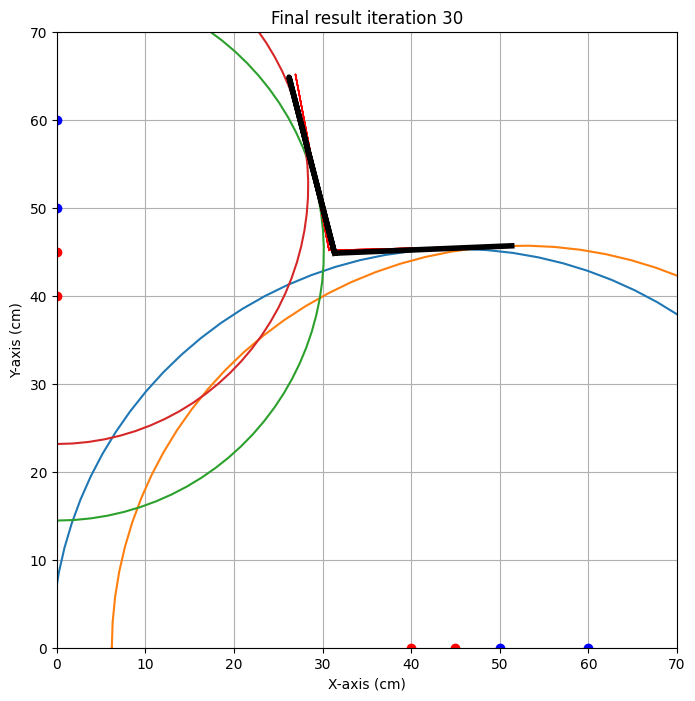

{'alpha': np.float64(2.3880082836241363), 'alpha_eps': np.float64(0.9164237180780475), 'beta': np.float64(-14.418258870723221), 'beta_eps': np.float64(3.6720133491756037), 'x0': np.float64(31.35089962929798), 'x0_eps': np.float64(0.625079084889741), 'y0': np.float64(44.836224809966204), 'y0_eps': np.float64(0.32297819786487025)}
locatie 1 
x0 target is : 33.0. Gevonden waarde: 30.1 cm met een standaardafwijking van 0.6 cm 
y0 target is : 38.0. Gevonden waarde: 34.4 cm met een standaardafwijking van 0.5 cm 
alpha target is : 1.0. Gevonden waarde: 3.3 graden met een standaardafwijking van 2.8 graad 
beta target is : 1.0. Gevonden waarde: 0.5 graden met een standaardafwijking van 1.9 graad 

locatie 2 
x0 target is : 33.0. Gevonden waarde: 31.4 cm met een standaardafwijking van 0.6 cm 
y0 target is : 38.0. Gevonden waarde: 44.8 cm met een standaardafwijking van 0.3 cm 
alpha target is : 1.0. Gevonden waarde: 2.4 graden met een standaardafwijking van 0.9 graad 
beta target is : 1.0. Gevond

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 30,
           'y0': 35,
           'alpha': 1,
           'beta' : 1
          },
           'locatie 2':{'x0': 31,
           'y0': 45,
           'alpha': 1,
           'beta' : 1
          }
            }

           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [40,0,50,0,45.87],
    [45,0,60,0,53.12],
    
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](schets1.jpeg "Versie 1 algoritme")

Figuur: ![Alt](schets.jpeg "Laatste versie algoritme")

Figuur: ![Alt](tudelftLogo.png "Title")

Gemaakte evaluatie
Beslissingen/verandering

In [ ]:
#Resulaat
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))